In [1]:
pip install numpy pandas matplotlib scikit-learn tensorflow flask pyserial

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

%matplotlib inline


In [3]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

%matplotlib inline


In [4]:
# ===============================
# DATASET DIRECTORY
# ===============================
BASE_DIR = r"C:\Users\Divyansh\Downloads\project"

# ===============================
# DATASETS (ALL 8 FILES)
# ===============================
working_files = {
    f"{BASE_DIR}\\Painting_fixed_augmented.csv": 1,
    f"{BASE_DIR}\\Sawing_fixed_augmented.csv": 1,
    f"{BASE_DIR}\\Screwing_fixed_augmented.csv": 1,
    f"{BASE_DIR}\\Lifting load_fixed_augmented.csv": 1,
    f"{BASE_DIR}\\Masonry_fixed_augmented.csv": 1,
    f"{BASE_DIR}\\Hammering_fixed_augmented.csv": 1
}

not_working_files = {
    f"{BASE_DIR}\\Sitting_fixed_augmented.csv": 0,
    f"{BASE_DIR}\\Standing_fixed_augmented.csv": 0
}
dfs = []

for file, label in working_files.items():
    df = pd.read_csv(file)
    df["binary_label"] = label
    dfs.append(df)

for file, label in not_working_files.items():
    df = pd.read_csv(file)
    df["binary_label"] = label
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data.head()


,time,xacc,yacc,zacc,total_acc,label,binary_label
0,0.002672,-0.494285,0.050563,0.294991,0.577836,3,1
1,0.003541,-0.483347,0.056258,0.380120,0.617479,3,1
2,0.004012,-0.348829,0.036964,0.474675,0.590224,3,1
3,0.008640,-0.175873,-0.040488,0.514803,0.545521,3,1
4,0.011632,0.038169,-0.264110,0.466215,0.537185,3,1


In [5]:
X_raw = data[["xacc", "yacc", "zacc"]].values
y_raw = data["binary_label"].values

X_raw.shape, y_raw.shape


((177545, 3), (177545,))

In [6]:
def create_windows(X, y, window_size=50):
    X_windows = []
    y_windows = []

    for i in range(len(X) - window_size):
        X_windows.append(X[i:i + window_size])
        y_windows.append(y[i])   

    return np.array(X_windows), np.array(y_windows)

In [7]:
WINDOW_SIZE = 50
X, y = create_windows(X_raw, y_raw, WINDOW_SIZE)

X.shape, y.shape


((177495, 50, 3), (177495,))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train.reshape(-1, 3)
).reshape(X_train.shape)

X_test = scaler.transform(
    X_test.reshape(-1, 3)
).reshape(X_test.shape)


In [10]:
model = Sequential([
    Input(shape=(WINDOW_SIZE, 3)),
    Conv1D(64, 3, activation="relu"),
    MaxPooling1D(2),
    Conv1D(128, 3, activation="relu"),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 48, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 22, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        90,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,585 (451.50 KB)

 Trainable params: 115,585 (451.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
3550/3550 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9464 - loss: 0.1291 - val_accuracy: 0.9750 - val_loss: 0.0617
Epoch 2/15
3550/3550 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9849 - loss: 0.0426 - val_accuracy: 0.9938 - val_loss: 0.0222
Epoch 3/15
3550/3550 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9919 - loss: 0.0243 - val_accuracy: 0.9962 - val_loss: 0.0112
Epoch 4/15
3550/3550 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9945 - loss: 0.0155 - val_accuracy: 0.9974 - val_loss: 0.0070
Epoch 5/15
3550/3550 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9956 - loss: 0.0149 - val_accuracy: 0.9993 - val_loss: 0.0046
Epoch 6/15
3550/3550 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9963 - loss: 0.0136 - val_accuracy: 0.9990 - val_loss: 0.0035
Epoch 7/15
3550/3550 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9971 - loss: 0.0085 - val_accuracy: 0.9962 - val_loss: 0.0136
Epoch 8/15
3550/3550 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9971 - loss: 0

In [12]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


1110/1110 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9979 - loss: 0.0063
Test Accuracy: 0.9979154467582703


1110/1110 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


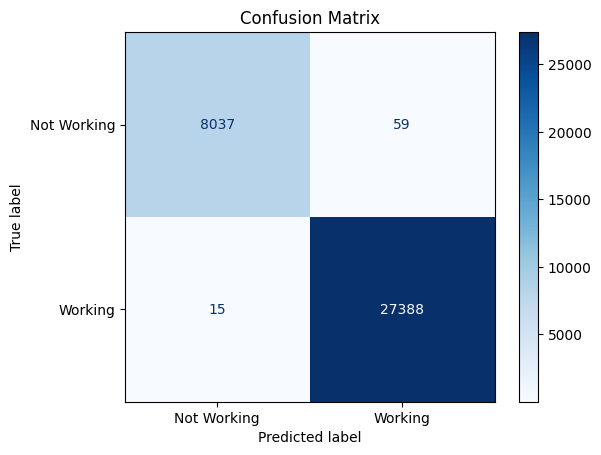

In [13]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Working", "Working"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


1110/1110 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


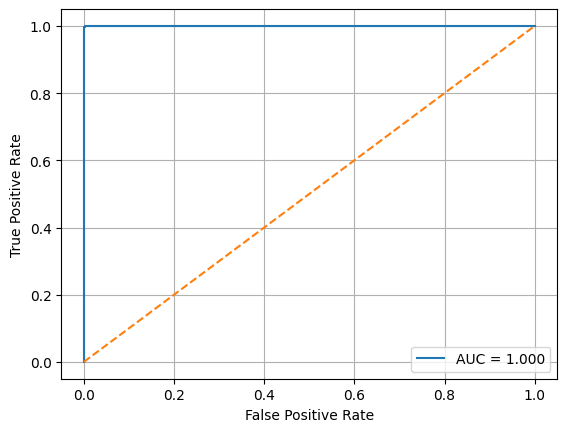

In [14]:
y_prob = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
from flask import Flask, jsonify
import serial
import numpy as np
import time
import joblib
from tensorflow.keras.models import load_model
from collections import deque

# ======================
# INIT
# ======================
app = Flask(__name__)

# ======================
# LOAD MODEL & SCALER
# ======================
model = load_model("model.keras")
scaler = joblib.load("scaler.pkl")

# ======================
# SERIAL CONNECTION
# ======================
try:
    ser = serial.Serial('COM7', 9600, timeout=1)
    time.sleep(2)
    print("Serial Connected")
except:
    ser = None
    print(" Serial Not Connected")

# ======================
# BUFFER FOR SMOOTHING
# ======================
buffer = deque(maxlen=10)

# ======================
# FUNCTION: READ + PREDICT
# ======================
def get_prediction():
    global buffer

    if ser is None:
        return {"status": "ERROR", "message": "Serial not connected"}

    try:
        line = ser.readline().decode('utf-8').strip()

        if not line:
            return {"status": "NO DATA"}

        print("RAW:", line)

        # Convert to float
        values = list(map(float, line.split(',')))

        # ======================
        # 🔥 MOVEMENT CHECK (IMPORTANT)
        # ======================
        if max(values) < 0.2:   # adjust based on sensor
            return {"status": "IDLE", "reason": "No movement detected"}

        # ======================
        # SCALE INPUT
        # ======================
        input_data = np.array(values).reshape(1, -1)
        input_scaled = scaler.transform(input_data)

        # ======================
        # MODEL PREDICTION
        # ======================
        pred = model.predict(input_scaled, verbose=0)[0][0]

        # ======================
        # SMOOTHING
        # ======================
        buffer.append(pred)
        avg_pred = sum(buffer) / len(buffer)

        # ======================
        # FINAL DECISION
        # ======================
        if avg_pred > 0.92:
            status = "WORKING"
        else:
            status = "IDLE"

        print(f"Values: {values}")
        print(f"Prediction: {pred:.3f}, Avg: {avg_pred:.3f}, Status: {status}")

        return {
            "status": status,
            "raw_prediction": float(pred),
            "smoothed_prediction": float(avg_pred),
            "values": values
        }

    except Exception as e:
        print("Error:", e)
        return {"status": "ERROR", "message": str(e)}

# ======================
# API ROUTE
# ======================
@app.route('/data')
def data():
    return jsonify(get_prediction())

# ======================
# HOME ROUTE
# ======================
@app.route('/')
def home():
    return """
    <h2>👷 Labour Monitoring System</h2>
    <p>Go to <a href="/data">/data</a> to see live prediction</p>
    """

# ======================
# RUN APP
# ======================
if __name__ == '__main__':
    app.run(debug=True)

 Serial Not Connected
 * Serving Flask app '__main__'
 * Debug mode: on


c:\Users\Divyansh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1

C:\Users\Divyansh\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
